In [1]:
!python -V

Python 3.14.3


In [2]:
import pickle

In [3]:
import pandas as pd

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import root_mean_squared_error

In [6]:
df = pd.read_parquet('./data/green_tripdata_2021-01.parquet')

df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.dt.total_seconds() / 60

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [7]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

root_mean_squared_error(y_train, y_pred)

9.838799799829625

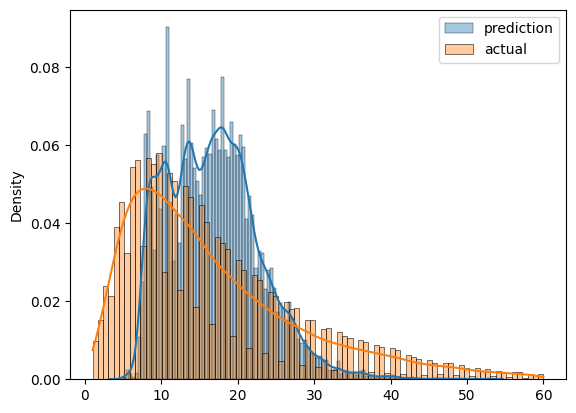

In [8]:
sns.histplot(y_pred, label='prediction', kde=True, stat="density", alpha=.4)
sns.histplot(y_train, label='actual', kde=True, stat="density", alpha=.4)

plt.legend()
plt.show()

In [9]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.dt.total_seconds() / 60

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)

    return df

In [10]:
df_train = read_dataframe('./data/green_tripdata_2021-01.parquet')
df_val = read_dataframe('./data/green_tripdata_2021-02.parquet')

In [11]:
len(df_train), len(df_val)

(73908, 61921)

In [12]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [13]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [14]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [15]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

7.7587152048642825

In [16]:
with open('./models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [17]:
lr = Lasso(0.01)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

11.167275942353895

# MLFlow

## Lasso

In [1]:
import mlflow

mlflow.set_experiment("nyc-taxi-experiment")

<Experiment: artifact_location='mlflow-artifacts:/3', creation_time=1777208039466, experiment_id='3', last_update_time=1777208039466, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}, trace_location=None, workspace='default'>

In [19]:
with mlflow.start_run():

    mlflow.set_tag("developer", "cristian")

    mlflow.log_param("train-data-path", "./data/green_tripdata_2021-01.csv")
    mlflow.log_param("valid-data-path", "./data/green_tripdata_2021-02.csv")

    alpha = 0.01
    mlflow.log_param("alpha", alpha)
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

    mlflow.log_artifact(local_path="models/lin_reg.bin", artifact_path="models_pickle")

🏃 View run redolent-moth-474 at: http://mlflow:5000/#/experiments/3/runs/09fce13844c14e8e88ef20002a7f2d46
🧪 View experiment at: http://mlflow:5000/#/experiments/3


## XGBoost

In [19]:
import xgboost as xgb

In [20]:
import optuna

In [21]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [22]:
def objective(trial):
    # Setting nested=True will create a child run under the parent run.
    with mlflow.start_run(nested=True, run_name=f"trial_{trial.number}") as child_run:
        params = {
            "max_depth": trial.suggest_int("max_depth", 4, 100),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1e-0, log=True),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 1e-1, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-6, 1e-1, log=True),
            "min_child_weight": trial.suggest_float("min_child_weight", 1e-1, 1e3, log=True),
            "objective": "reg:squarederror",
            "random_state": 42,
        }
        # Log current trial's parameters
        mlflow.log_params(params)

        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, "validation")],
            early_stopping_rounds=50,
        )

        y_pred = booster.predict(
            data=valid,
            iteration_range=(0, booster.best_iteration + 1)
        )
        error = root_mean_squared_error(y_val, y_pred)
        # Log current trial's error metric
        mlflow.log_metric("error", error)

        # Make it easy to retrieve the best-performing child run later
        trial.set_user_attr("run_id", child_run.info.run_id)
        return error


In [ ]:
# Create a parent run that contains all child runs for different trials
with mlflow.start_run(run_name="study") as run:
    # Log the experiment settings
    n_trials = 50
    mlflow.log_param("n_trials", n_trials)

    study = optuna.create_study(
        sampler=optuna.samplers.TPESampler(seed=42),
        direction='minimize'
    )
    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=1,
        show_progress_bar=True
    )

    # Log the best trial and its run ID
    mlflow.log_params(study.best_trial.params)
    mlflow.log_metrics({"best_error": study.best_value})
    if best_run_id := study.best_trial.user_attrs.get("run_id"):
        mlflow.log_param("best_child_run_id", best_run_id)

[I 2026-05-03 10:29:46,619] A new study created in memory with name: no-name-3563a2dd-69cd-4487-a218-c525c9719a7b


  0%|          | 0/50 [00:00<?, ?it/s]

[0]	validation-rmse:7.51590
[1]	validation-rmse:6.82311
[2]	validation-rmse:6.71641
[3]	validation-rmse:6.68366
[4]	validation-rmse:6.67478
[5]	validation-rmse:6.66621
[6]	validation-rmse:6.66059
[7]	validation-rmse:6.65346
[8]	validation-rmse:6.64543
[9]	validation-rmse:6.63785
[10]	validation-rmse:6.63104
[11]	validation-rmse:6.62666
[12]	validation-rmse:6.62507
[13]	validation-rmse:6.62108
[14]	validation-rmse:6.61780
[15]	validation-rmse:6.61308
[16]	validation-rmse:6.60985
[17]	validation-rmse:6.60875
[18]	validation-rmse:6.60703
[19]	validation-rmse:6.60586
[20]	validation-rmse:6.60271
[21]	validation-rmse:6.59903
[22]	validation-rmse:6.59846
[23]	validation-rmse:6.59572
[24]	validation-rmse:6.59348
[25]	validation-rmse:6.59272
[26]	validation-rmse:6.59303
[27]	validation-rmse:6.59220
[28]	validation-rmse:6.58980
[29]	validation-rmse:6.58742
[30]	validation-rmse:6.58628
[31]	validation-rmse:6.58848
[32]	validation-rmse:6.58624
[33]	validation-rmse:6.58377
[34]	validation-rmse:6.5

### Manual logging

In [24]:
mlflow.xgboost.autolog(disable=True)

with mlflow.start_run():

    train = xgb.DMatrix(X_train, label=y_train)
    valid = xgb.DMatrix(X_val, label=y_val)

    best_params = {
        "max_depth": 44,
        "learning_rate": 0.1719747846289316,
        "reg_alpha": 4.896614873911946e-05,
        "reg_lambda": 0.019446810721081013,
        "min_child_weight": 1.785047439733004,
        "objective": "reg:squarederror",
        "random_state": 42
    }

    mlflow.log_params(best_params)

    booster = xgb.train(
        params=best_params,
        dtrain=train,
        num_boost_round=1000,
        evals=[(valid, 'validation')],
        early_stopping_rounds=50
    )

    y_pred = booster.predict(
        data=valid,
        iteration_range=(0, booster.best_iteration + 1)
    )
    error = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("error", error)

    with open("models/preprocessor.pkl", "wb") as f_out:
        pickle.dump(dv, f_out)
    mlflow.log_artifact("models/preprocessor.pkl", artifact_path="preprocessor")

    mlflow.xgboost.log_model(booster, name="models_mlflow")


[0]	validation-rmse:10.84339
[1]	validation-rmse:9.78065
[2]	validation-rmse:8.96328
[3]	validation-rmse:8.34365
[4]	validation-rmse:7.87984
[5]	validation-rmse:7.53790
[6]	validation-rmse:7.27768
[7]	validation-rmse:7.08854
[8]	validation-rmse:6.94774
[9]	validation-rmse:6.84248
[10]	validation-rmse:6.76135
[11]	validation-rmse:6.70150
[12]	validation-rmse:6.65752
[13]	validation-rmse:6.61963
[14]	validation-rmse:6.59121
[15]	validation-rmse:6.56832
[16]	validation-rmse:6.54906
[17]	validation-rmse:6.53404
[18]	validation-rmse:6.52137
[19]	validation-rmse:6.51207
[20]	validation-rmse:6.50120
[21]	validation-rmse:6.49439
[22]	validation-rmse:6.48815
[23]	validation-rmse:6.48317
[24]	validation-rmse:6.47965
[25]	validation-rmse:6.47684
[26]	validation-rmse:6.47435
[27]	validation-rmse:6.47275
[28]	validation-rmse:6.47164
[29]	validation-rmse:6.46959
[30]	validation-rmse:6.46840
[31]	validation-rmse:6.46695
[32]	validation-rmse:6.46507
[33]	validation-rmse:6.46306
[34]	validation-rmse:6.

2026/05/05 14:02:45 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lyrical-eel-58 at: http://mlflow:5000/#/experiments/3/runs/ca6d98c602904d7e9bfee6d08be32d60
🧪 View experiment at: http://mlflow:5000/#/experiments/3


### Autologging

In [25]:
mlflow.xgboost.autolog()

train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

best_params = {
    "max_depth": 44,
    "learning_rate": 0.1719747846289316,
    "reg_alpha": 4.896614873911946e-05,
    "reg_lambda": 0.019446810721081013,
    "min_child_weight": 1.785047439733004,
    "objective": "reg:squarederror",
    "random_state": 42
}

booster = xgb.train(
    params=best_params,
    dtrain=train,
    num_boost_round=1000,
    evals=[(valid, 'validation')],
    early_stopping_rounds=50
)

2026/05/05 14:04:11 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'b2cc9b7375fd4da298456fc1a802b46d', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow


[0]	validation-rmse:10.84339
[1]	validation-rmse:9.78065
[2]	validation-rmse:8.96328
[3]	validation-rmse:8.34365
[4]	validation-rmse:7.87984
[5]	validation-rmse:7.53790
[6]	validation-rmse:7.27768
[7]	validation-rmse:7.08854
[8]	validation-rmse:6.94774
[9]	validation-rmse:6.84248
[10]	validation-rmse:6.76135
[11]	validation-rmse:6.70150
[12]	validation-rmse:6.65752
[13]	validation-rmse:6.61963
[14]	validation-rmse:6.59121
[15]	validation-rmse:6.56832
[16]	validation-rmse:6.54906
[17]	validation-rmse:6.53404
[18]	validation-rmse:6.52137
[19]	validation-rmse:6.51207
[20]	validation-rmse:6.50120
[21]	validation-rmse:6.49439
[22]	validation-rmse:6.48815
[23]	validation-rmse:6.48317
[24]	validation-rmse:6.47965
[25]	validation-rmse:6.47684
[26]	validation-rmse:6.47435
[27]	validation-rmse:6.47275
[28]	validation-rmse:6.47164
[29]	validation-rmse:6.46959
[30]	validation-rmse:6.46840
[31]	validation-rmse:6.46695
[32]	validation-rmse:6.46507
[33]	validation-rmse:6.46306
[34]	validation-rmse:6.

2026/05/05 14:05:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 14:05:24 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run silent-shrimp-312 at: http://mlflow:5000/#/experiments/3/runs/b2cc9b7375fd4da298456fc1a802b46d
🧪 View experiment at: http://mlflow:5000/#/experiments/3


### Load model

In [ ]:
# logged_model = "runs:/ca6d98c602904d7e9bfee6d08be32d60/models_mlflow"
logged_model = "models:/m-f4dc893d9a0f4683835886094078e555"

mlflow.pyfunc.load_model(logged_model)

mlflow.pyfunc.loaded_model:
  artifact_path: mlflow-artifacts:/3/models/m-f4dc893d9a0f4683835886094078e555/artifacts
  flavor: mlflow.xgboost
  run_id: ca6d98c602904d7e9bfee6d08be32d60

In [4]:
# logged_model = "runs:/ca6d98c602904d7e9bfee6d08be32d60/models_mlflow"
logged_model = "models:/m-f4dc893d9a0f4683835886094078e555"

mlflow.xgboost.load_model(logged_model)

## scikit-learn

In [25]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import LinearSVR

mlflow.sklearn.autolog(disable=True)

for model_class, model_params in (
    (RandomForestRegressor, {"n_jobs": -1}),
    (GradientBoostingRegressor, {}),
    (ExtraTreesRegressor, {"n_jobs": -1}),
    (LinearSVR, {}),
):

    with mlflow.start_run():

        mlflow.log_param("train-data-path", "./data/green_tripdata_2021-01.csv")
        mlflow.log_param("valid-data-path", "./data/green_tripdata_2021-02.csv")
        mlflow.log_artifact("models/preprocessor.pkl", artifact_path="preprocessor")

        mlmodel = model_class(**model_params)
        mlmodel.fit(X_train, y_train)

        y_pred = mlmodel.predict(X_val)
        error = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("error", error)


🏃 View run brawny-cod-812 at: http://mlflow:5000/#/experiments/3/runs/1ed39db906814cb699b91c9c2c654bba
🧪 View experiment at: http://mlflow:5000/#/experiments/3
🏃 View run capricious-smelt-524 at: http://mlflow:5000/#/experiments/3/runs/c544f9555a4d425fa26622eae8753cc9
🧪 View experiment at: http://mlflow:5000/#/experiments/3
🏃 View run caring-flea-138 at: http://mlflow:5000/#/experiments/3/runs/5bdd546e709f48ff9faac75534bff4f8
🧪 View experiment at: http://mlflow:5000/#/experiments/3
🏃 View run popular-hound-885 at: http://mlflow:5000/#/experiments/3/runs/a7bf5ccc7be44fa7b8e2619fa77e8090
🧪 View experiment at: http://mlflow:5000/#/experiments/3


/app/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
